# Section 1.2.3 — Première modélisation : files de Poisson indépendantes

Ce notebook répond aux questions de la section **1.2.3** du sujet MODAL Queue Reactive.
On modélise les deux premières limites du carnet d'ordres par deux files indépendantes
$Q_1$ et $Q_{-1}$. Chaque file reçoit des ajouts au taux $\lambda^\oplus$
et des retraits au taux $\lambda^\ominus$.

Les paramètres de référence sont ceux de l'énoncé :

$$
\lambda^\oplus = 1.2,\qquad \lambda^\ominus = 1.5,\qquad
Q_1(0)=Q_{-1}(0)=10.
$$

La convention utilisée dans les figures est la suivante : $Q_1$ désigne la
première limite ask et $Q_{-1}$ la première limite bid. Le temps d'arrêt est

$$
T_{\min}=\inf\{t\ge 0:\min(Q_1(t),Q_{-1}(t))=0\}.
$$


In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from model.hitting_times import (
    simulate_until_hit_zero,
    simulate_brownian_until_hit_zero,
    hitting_time_pdf_brownian,
    hitting_time_cdf_brownian,
    hitting_time_mean_brownian,
    prob_q1_hits_first_brownian,
    batch_hitting_times,
    scan_initial_conditions,
)
from model.Hawkes import (
    prob_reach_zero_discrete,
    prob_reach_zero_brownian,
    compare_hitting_probabilities,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
LAMBDA_PLUS = 1.2
LAMBDA_MINUS = 1.5
Q0 = 10
MU = LAMBDA_PLUS - LAMBDA_MINUS
SIGMA = np.sqrt(LAMBDA_PLUS + LAMBDA_MINUS)
print(f"Paramètres : λ⁺={LAMBDA_PLUS}, λ⁻={LAMBDA_MINUS}, μ={MU:.2f}, σ={SIGMA:.3f}, Q₀={Q0}")


Paramètres : λ⁺=1.2, λ⁻=1.5, μ=-0.30, σ=1.643, Q0=10


## Question 1.2.3.0 — Simulation de base

On simule les deux files jusqu'à ce que l'une d'entre elles atteigne zéro. La première
figure représente les trajectoires temporelles, et la seconde représente le
chemin dans le quadrant $(Q_1,Q_{-1})$, comme dans l'esprit de la Figure 2
du sujet.


Temps d'arrêt : 13.4866
File qui touche zéro : Q₁
Nombre d'événements : 73
État final : Q₁=0, Q₋₁=13


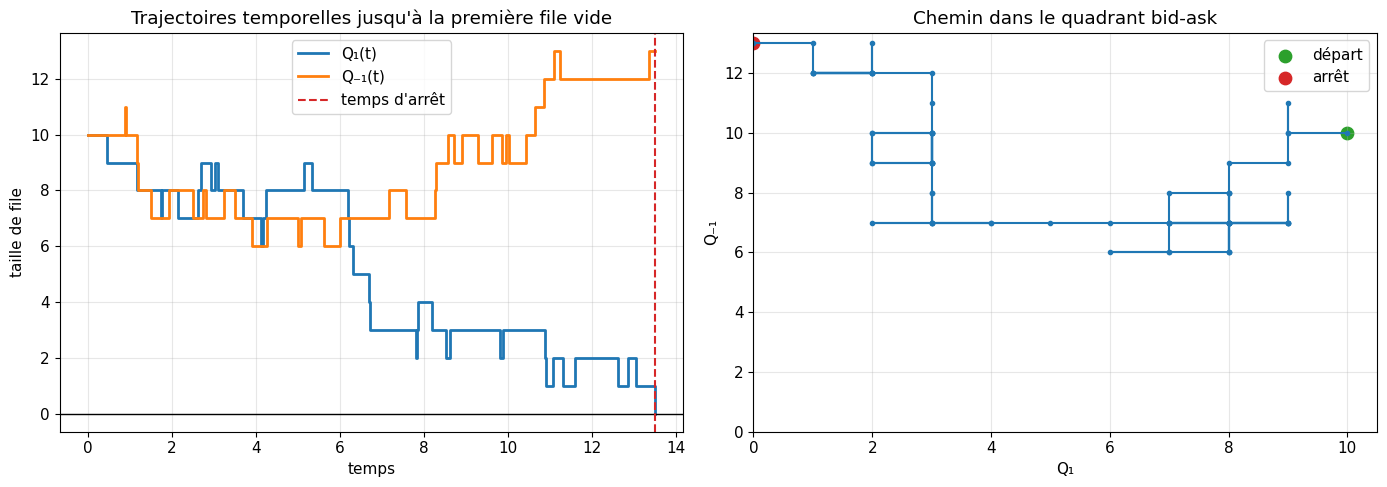

In [2]:
rng = np.random.default_rng(SEED)
res_base = simulate_until_hit_zero(
    q1_init=Q0,
    q_neg1_init=Q0,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    rng=rng,
    record_path=True,
)

file_touchee = "Q₁" if res_base.which_hit == 1 else "Q₋₁"
print(f"Temps d'arrêt : {res_base.hitting_time:.4f}")
print(f"File qui touche zéro : {file_touchee}")
print(f"Nombre d'événements : {len(res_base.times) - 1}")
print(f"État final : Q₁={res_base.q1_final}, Q₋₁={res_base.q_neg1_final}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].step(res_base.times, res_base.q1_path, where="post", label="Q₁(t)", linewidth=2)
axes[0].step(res_base.times, res_base.q_neg1_path, where="post", label="Q₋₁(t)", linewidth=2)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axvline(res_base.hitting_time, color="tab:red", linestyle="--", label="temps d'arrêt")
axes[0].set_xlabel("temps")
axes[0].set_ylabel("taille de file")
axes[0].set_title("Trajectoires temporelles jusqu'à la première file vide")
axes[0].legend()

axes[1].plot(res_base.q1_path, res_base.q_neg1_path, marker="o", markersize=3, linewidth=1.5)
axes[1].scatter([res_base.q1_path[0]], [res_base.q_neg1_path[0]], color="tab:green", s=80, label="départ")
axes[1].scatter([res_base.q1_path[-1]], [res_base.q_neg1_path[-1]], color="tab:red", s=80, label="arrêt")
axes[1].set_xlabel("Q₁")
axes[1].set_ylabel("Q₋₁")
axes[1].set_title("Chemin dans le quadrant bid-ask")
axes[1].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
axes[1].legend()

plt.tight_layout()
plt.show()


**Interprétation.** Le chemin s'arrête dès qu'une coordonnée atteint l'axe.
Comme $\lambda^\ominus>\lambda^\oplus$, chaque file a un drift négatif
$\mu=\lambda^\oplus-\lambda^\ominus=-0.3$, ce qui rend l'atteinte de zéro
presque sûre pour chaque file prise séparément.


## Question 1.2.3.1 — Approximation brownienne

Pour une file $Q$, on écrit exactement

$$
Q(t)=Q(0)+N^\oplus(t)-N^\ominus(t),
$$

où $N^\oplus(t)\sim \mathrm{Poi}(\lambda^\oplus t)$ et
$N^\ominus(t)\sim \mathrm{Poi}(\lambda^\ominus t)$ sont indépendants.
Par additivité de l'espérance et de la variance pour des variables
indépendantes,

$$
\mathbb{E}[Q(t)]
=Q(0)+\lambda^\oplus t-\lambda^\ominus t
=Q(0)+\mu t,
$$

avec $\mu=\lambda^\oplus-\lambda^\ominus$. De même,

$$
\mathrm{Var}(Q(t))
=\mathrm{Var}(N^\oplus(t))+\mathrm{Var}(N^\ominus(t))
=\lambda^\oplus t+\lambda^\ominus t
=\sigma^2 t,
$$

où $\sigma^2=\lambda^\oplus+\lambda^\ominus$.

Le théorème central limite fonctionnel appliqué aux deux processus de Poisson
donne, à l'échelle diffusive,

$$
Q(t)\approx Q(0)+\mu t+\sigma W_t,
$$

où $W$ est un mouvement brownien standard. Cette approximation conserve le
drift et la variance instantanée du processus birth-death discret.


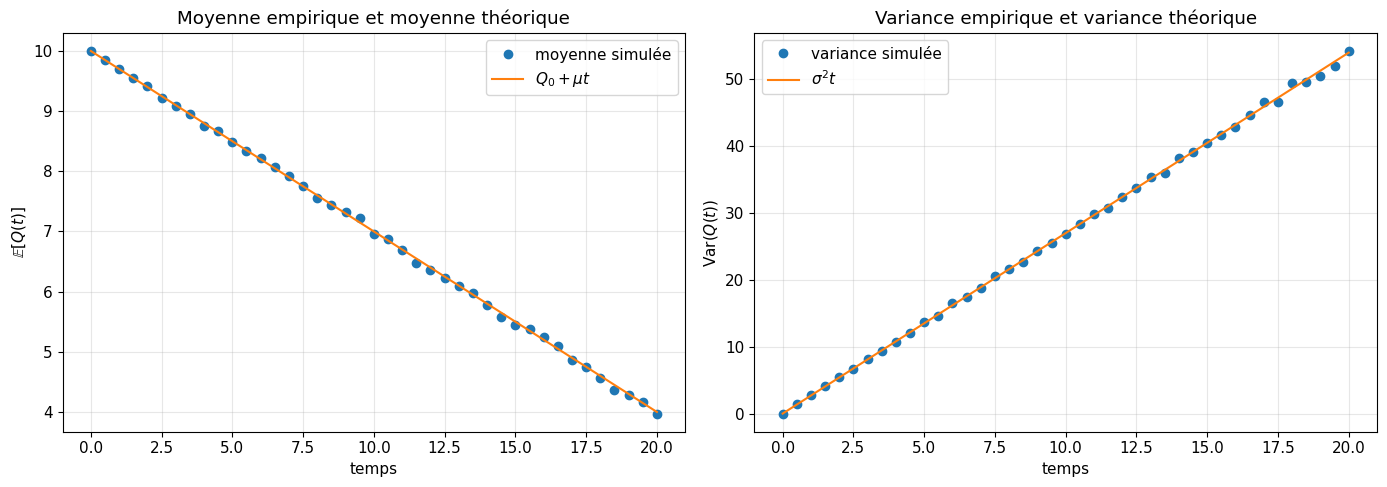

In [3]:
# Vérification numérique des moments sur la grille t = 0, 0.5, ..., 20.
rng = np.random.default_rng(SEED)
t_grid = np.arange(0, 20.5, 0.5)
n_paths_moments = 20_000

echantillons = (
    Q0
    + rng.poisson(LAMBDA_PLUS * t_grid, size=(n_paths_moments, len(t_grid)))
    - rng.poisson(LAMBDA_MINUS * t_grid, size=(n_paths_moments, len(t_grid)))
)

moy_emp = echantillons.mean(axis=0)
var_emp = echantillons.var(axis=0, ddof=1)
moy_theo = Q0 + MU * t_grid
var_theo = SIGMA**2 * t_grid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_grid, moy_emp, "o", label="moyenne simulée")
axes[0].plot(t_grid, moy_theo, "-", label=r"$Q_0+\mu t$")
axes[0].set_xlabel("temps")
axes[0].set_ylabel(r"$\mathbb{E}[Q(t)]$")
axes[0].set_title("Moyenne empirique et moyenne théorique")
axes[0].legend()

axes[1].plot(t_grid, var_emp, "o", label="variance simulée")
axes[1].plot(t_grid, var_theo, "-", label=r"$\sigma^2 t$")
axes[1].set_xlabel("temps")
axes[1].set_ylabel(r"$\mathrm{Var}(Q(t))$")
axes[1].set_title("Variance empirique et variance théorique")
axes[1].legend()

plt.tight_layout()
plt.show()


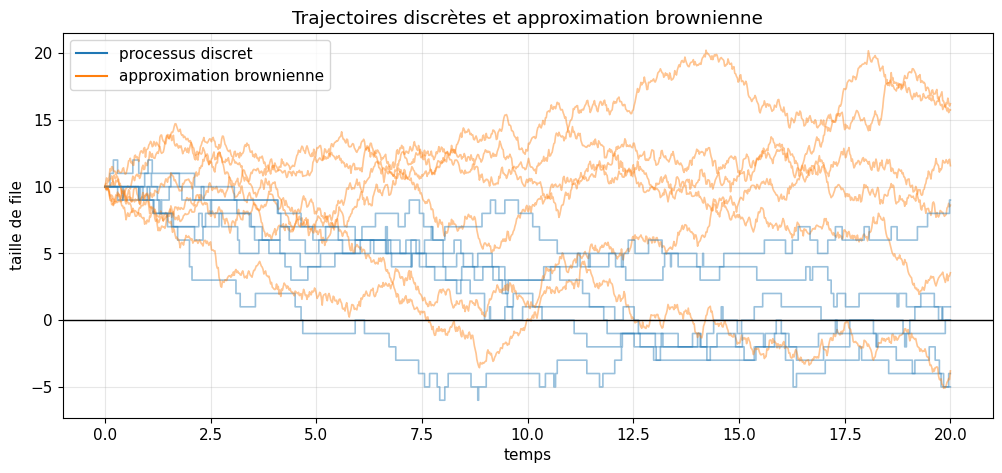

In [4]:
# Superposition de trajectoires discrètes et de trajectoires browniennes.
rng = np.random.default_rng(SEED)
T_plot = 20.0
dt_bm = 0.02
t_bm = np.arange(0, T_plot + dt_bm, dt_bm)
n_traj = 6

fig, ax = plt.subplots(figsize=(12, 5))

for k in range(n_traj):
    # Processus discret simulé par incréments indépendants sur la grille.
    add_inc = rng.poisson(LAMBDA_PLUS * dt_bm, size=len(t_bm) - 1)
    rem_inc = rng.poisson(LAMBDA_MINUS * dt_bm, size=len(t_bm) - 1)
    q_discret = Q0 + np.r_[0, np.cumsum(add_inc - rem_inc)]
    dW = rng.normal(0, np.sqrt(dt_bm), size=len(t_bm) - 1)
    W = np.r_[0.0, np.cumsum(dW)]
    q_bm = Q0 + MU * t_bm + SIGMA * W

    ax.step(t_bm, q_discret, where="post", alpha=0.45, linewidth=1.2, color="tab:blue")
    ax.plot(t_bm, q_bm, alpha=0.45, linewidth=1.2, color="tab:orange")

ax.axhline(0, color="black", linewidth=1)
ax.plot([], [], color="tab:blue", label="processus discret")
ax.plot([], [], color="tab:orange", label="approximation brownienne")
ax.set_xlabel("temps")
ax.set_ylabel("taille de file")
ax.set_title("Trajectoires discrètes et approximation brownienne")
ax.legend()
plt.show()


**Conclusion.** Les deux premiers moments coïncident avec les formules
théoriques. Les trajectoires browniennes sont continues et peuvent devenir
négatives, alors que la file discrète vit sur $\mathbb{Z}_+$ et s'arrête
au bord $0$. Cette différence devient importante pour les probabilités
d'atteinte étudiées en complément.


## Question 1.2.3.2 — Distribution des temps d'atteinte

Pour l'approximation brownienne

$$
X(t)=x_0+\mu t+\sigma W_t,\qquad \mu<0,
$$

le temps d'atteinte $T_0=\inf\{t:X(t)=0\}$ admet la densité inverse
gaussienne

$$
f(t)=\frac{x_0}{\sigma\sqrt{2\pi t^3}}
\exp\!\left(-\frac{(x_0+\mu t)^2}{2\sigma^2 t}\right),
\qquad t>0.
$$

On reproduit l'esprit de la Figure 3 : approximation brownienne, processus
de Poisson exact, puis superposition avec la densité théorique.


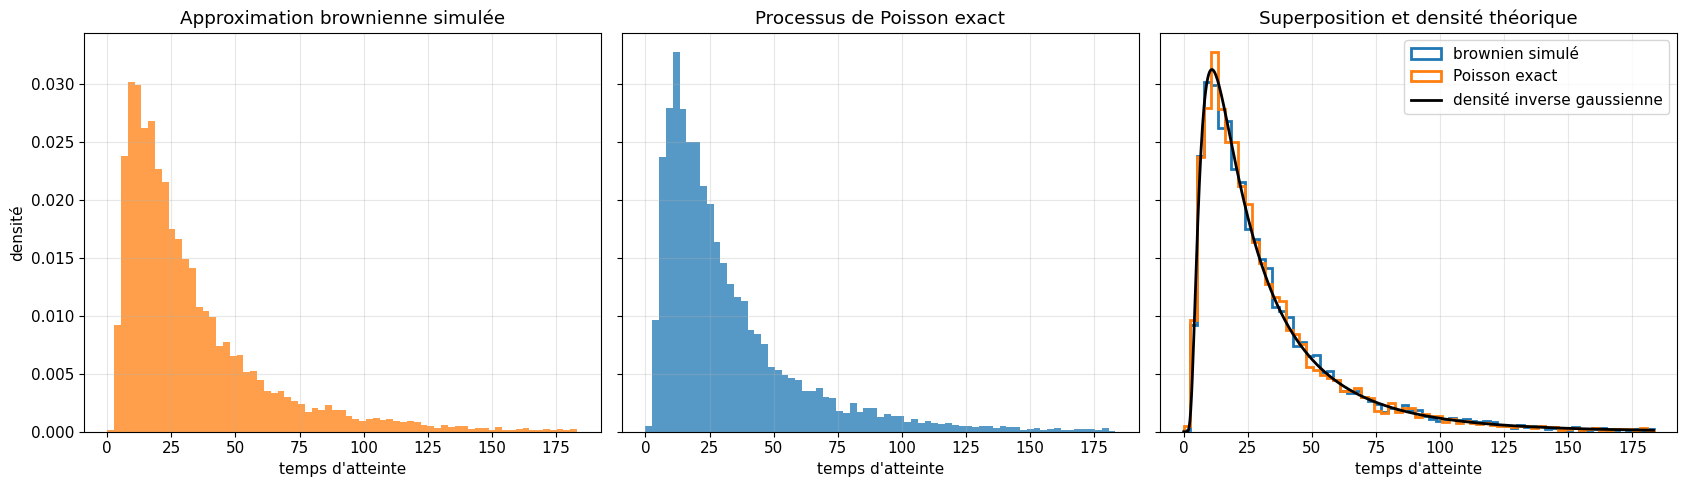

In [5]:
def simuler_temps_poisson_une_file(n_runs, q_init, lambda_plus, lambda_minus, rng, t_max=2_000.0):
    # Simule le temps d'atteinte de zéro pour une seule file birth-death.
    temps = np.empty(n_runs)
    for k in range(n_runs):
        q = q_init
        t = 0.0
        taux_total = lambda_plus + lambda_minus
        while q > 0 and t < t_max:
            t += rng.exponential(1.0 / taux_total)
            if rng.random() < lambda_plus / taux_total:
                q += 1
            else:
                q -= 1
        temps[k] = t
    return temps


def echantillon_inverse_gaussienne_brownienne(n_runs, x0, mu, sigma, rng):
    # Échantillonnage exact de T₀ pour le brownien avec drift négatif.
    moyenne = x0 / abs(mu)
    forme = x0**2 / sigma**2
    v = rng.normal(size=n_runs)
    y = v**2
    racine = np.sqrt(4 * moyenne * forme * y + moyenne**2 * y**2)
    x = moyenne + (moyenne**2 * y) / (2 * forme) - (moyenne / (2 * forme)) * racine
    u = rng.random(n_runs)
    return np.where(u <= moyenne / (moyenne + x), x, moyenne**2 / x)


N_sim = 10_000
rng = np.random.default_rng(SEED)
temps_bm = echantillon_inverse_gaussienne_brownienne(N_sim, Q0, MU, SIGMA, rng)
temps_poisson = simuler_temps_poisson_une_file(N_sim, Q0, LAMBDA_PLUS, LAMBDA_MINUS, rng)

bins = np.linspace(0, np.quantile(np.r_[temps_bm, temps_poisson], 0.995), 70)
t_pdf = np.linspace(0.01, bins[-1], 600)
pdf_theo = hitting_time_pdf_brownian(t_pdf, Q0, MU, SIGMA)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

axes[0].hist(temps_bm, bins=bins, density=True, color="tab:orange", alpha=0.75)
axes[0].set_title("Approximation brownienne simulée")
axes[0].set_xlabel("temps d'atteinte")
axes[0].set_ylabel("densité")

axes[1].hist(temps_poisson, bins=bins, density=True, color="tab:blue", alpha=0.75)
axes[1].set_title("Processus de Poisson exact")
axes[1].set_xlabel("temps d'atteinte")

axes[2].hist(temps_bm, bins=bins, density=True, histtype="step", linewidth=2, label="brownien simulé")
axes[2].hist(temps_poisson, bins=bins, density=True, histtype="step", linewidth=2, label="Poisson exact")
axes[2].plot(t_pdf, pdf_theo, color="black", linewidth=2, label="densité inverse gaussienne")
axes[2].set_title("Superposition et densité théorique")
axes[2].set_xlabel("temps d'atteinte")
axes[2].legend()

plt.tight_layout()
plt.show()


**Interprétation.** La densité inverse gaussienne décrit très bien
l'approximation brownienne. Le processus discret présente une forme proche,
mais pas identique : il ne peut atteindre zéro qu'après un nombre entier de
retraits nets, et sa dynamique reste contrainte par la granularité des sauts.


## Question 1.2.3.3 — Temps moyen et intervalle de confiance

On estime par Monte Carlo

$$
\mathbb{E}[T_{\min}]
=\mathbb{E}[\min(T_1,T_{-1})].
$$

Pour $n$ simulations indépendantes, l'intervalle de confiance asymptotique
à 95 % est

$$
\left[\widehat\mu_n-1.96\frac{\widehat\sigma_n}{\sqrt{n}},
\widehat\mu_n+1.96\frac{\widehat\sigma_n}{\sqrt{n}}\right].
$$

Pour une seule file brownienne de drift négatif, la formule théorique est

$$
\mathbb{E}[T_{\mathrm{single}}]=\frac{x_0}{|\mu|}.
$$


Estimation de E[T_min] : 18.6299
Écart-type empirique : 13.7059
IC 95 % : [18.3613, 18.8985]
E[T_single] brownien théorique : 33.3333


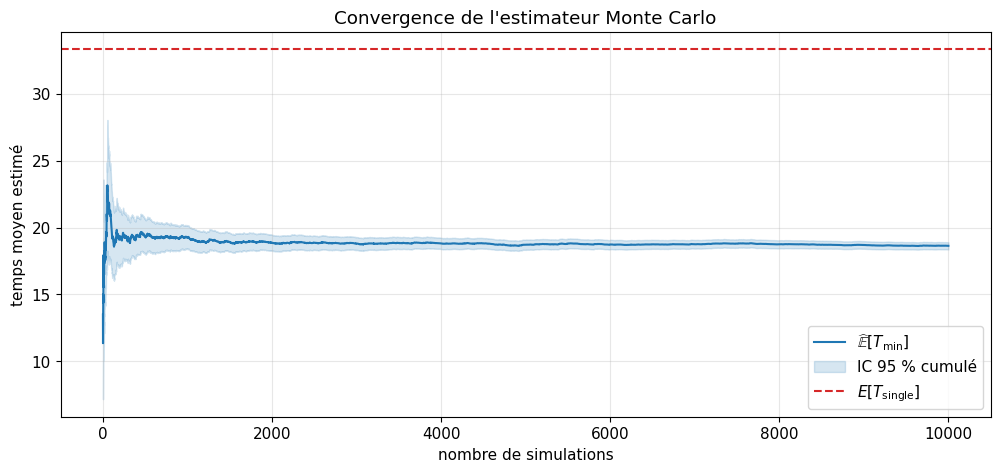

In [6]:
N_mc = 10_000
res_mc = batch_hitting_times(
    n_runs=N_mc,
    q1_init=Q0,
    q_neg1_init=Q0,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    seed=SEED,
)

temps_min = res_mc["hitting_times"]
print(f"Estimation de E[T_min] : {res_mc['mean_T']:.4f}")
print(f"Écart-type empirique : {res_mc['std_T']:.4f}")
print(f"IC 95 % : [{res_mc['ci_95'][0]:.4f}, {res_mc['ci_95'][1]:.4f}]")
print(f"E[T_single] brownien théorique : {hitting_time_mean_brownian(Q0, MU):.4f}")

n = np.arange(1, N_mc + 1)
moy_cum = np.cumsum(temps_min) / n
cum_sum = np.cumsum(temps_min)
cum_sum2 = np.cumsum(temps_min**2)
var_cum = np.zeros_like(moy_cum)
var_cum[1:] = (cum_sum2[1:] - cum_sum[1:]**2 / n[1:]) / (n[1:] - 1)
demi_largeur = 1.96 * np.sqrt(var_cum / np.maximum(n, 1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(n, moy_cum, label=r"$\widehat{\mathbb{E}}[T_{\min}]$")
ax.fill_between(
    n[1:],
    moy_cum[1:] - demi_largeur[1:],
    moy_cum[1:] + demi_largeur[1:],
    color="tab:blue",
    alpha=0.18,
    label="IC 95 % cumulé",
)
ax.axhline(hitting_time_mean_brownian(Q0, MU), color="tab:red", linestyle="--", label=r"$E[T_{\mathrm{single}}]$")
ax.set_xlabel("nombre de simulations")
ax.set_ylabel("temps moyen estimé")
ax.set_title("Convergence de l'estimateur Monte Carlo")
ax.legend()
plt.show()


**Conclusion.** Le minimum de deux temps d'atteinte indépendants est
naturellement plus petit que le temps d'atteinte d'une file seule. La courbe
de convergence se stabilise autour de l'estimation Monte Carlo, tandis que la
largeur de l'intervalle de confiance décroît en $1/\sqrt{n}$.


## Question 1.2.3.4 — Temps moyen selon les conditions initiales

On balaie

$$
Q_1(0)\in\{2,4,\ldots,20\},\qquad
Q_{-1}(0)\in\{2,4,\ldots,20\}.
$$

Pour chaque point de la grille, on estime $\mathbb{E}[T_{\min}]$ par
Monte Carlo avec au moins $1000$ simulations.


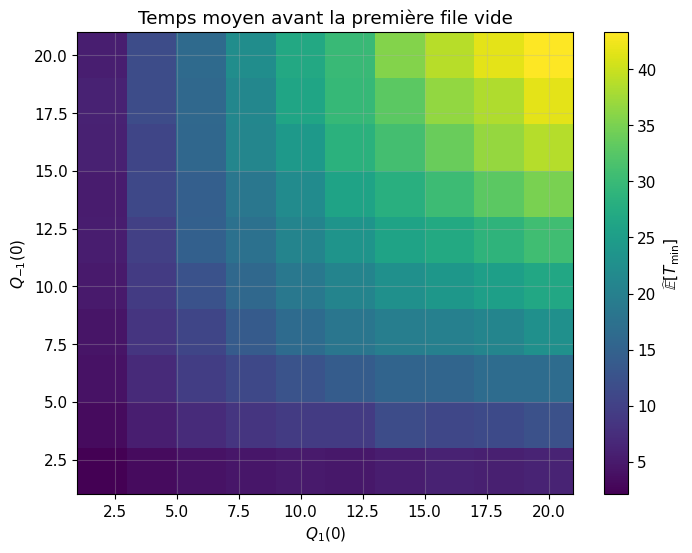

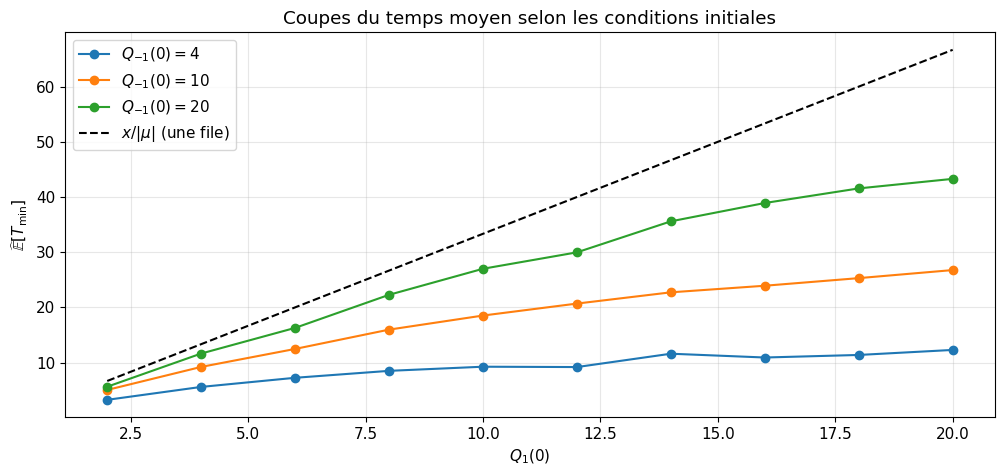

In [7]:
q_values = np.arange(2, 22, 2)
N_heatmap = 1_000

scan = scan_initial_conditions(
    q1_range=q_values,
    q_neg1_range=q_values,
    n_runs=N_heatmap,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    seed=SEED,
)

mean_T_grid = scan["mean_T_grid"]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    mean_T_grid,
    origin="lower",
    extent=[q_values[0]-1, q_values[-1]+1, q_values[0]-1, q_values[-1]+1],
    aspect="auto",
    cmap="viridis",
)
fig.colorbar(im, ax=ax, label=r"$\widehat{\mathbb{E}}[T_{\min}]$")
ax.set_xlabel(r"$Q_1(0)$")
ax.set_ylabel(r"$Q_{-1}(0)$")
ax.set_title("Temps moyen avant la première file vide")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for qn_fixed in [4, 10, 20]:
    idx = np.where(q_values == qn_fixed)[0][0]
    ax.plot(q_values, mean_T_grid[idx, :], marker="o", label=fr"$Q_{{-1}}(0)={qn_fixed}$")

ax.plot(q_values, q_values / abs(MU), color="black", linestyle="--", label=r"$x/|\mu|$ (une file)")
ax.set_xlabel(r"$Q_1(0)$")
ax.set_ylabel(r"$\widehat{\mathbb{E}}[T_{\min}]$")
ax.set_title("Coupes du temps moyen selon les conditions initiales")
ax.legend()
plt.show()


**Interprétation.** Le temps moyen augmente avec les tailles initiales des
deux files. Les coupes restent sous la courbe $x/|\mu|$, car le système
s'arrête dès que l'une des deux files atteint zéro.


## Question 1.2.3.5 — Probabilité que $Q_1$ touche zéro en premier

On estime

$$
\mathbb{P}(T_1<T_{-1})
$$

sur la même grille de conditions initiales. Pour l'approximation brownienne,
l'expression utilisée est

$$
\mathbb{P}(T_1<T_{-1})
=\int_0^\infty f_{T_1}(t)\left(1-F_{T_{-1}}(t)\right)\,dt,
$$

où $f_{T_1}$ est la densité inverse gaussienne de $T_1$ et
$F_{T_{-1}}$ la fonction de répartition de $T_{-1}$.


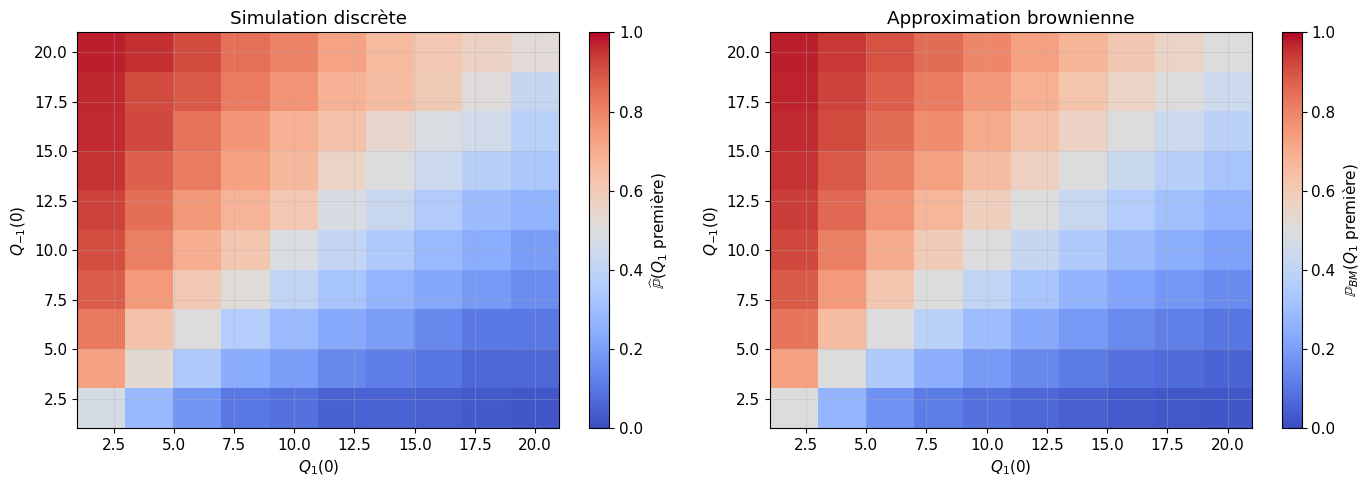

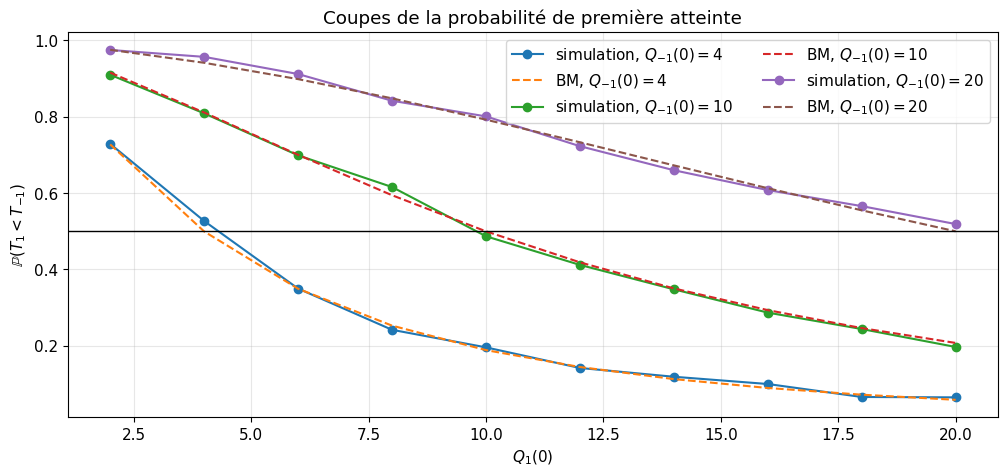

Probabilités simulées sur la diagonale : [0.47  0.527 0.503 0.508 0.487 0.484 0.493 0.487 0.506 0.519]
Écart maximal à 0.5 sur la diagonale : 0.030


In [8]:
prob_q1_grid = scan["prob_q1_grid"]

prob_bm_grid = np.zeros_like(prob_q1_grid)
for j, qn in enumerate(q_values):
    for i, q1 in enumerate(q_values):
        prob_bm_grid[j, i] = prob_q1_hits_first_brownian(q1, qn, MU, SIGMA)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(
    prob_q1_grid,
    origin="lower",
    extent=[q_values[0]-1, q_values[-1]+1, q_values[0]-1, q_values[-1]+1],
    vmin=0,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)
fig.colorbar(im0, ax=axes[0], label=r"$\widehat{\mathbb{P}}(Q_1\ \mathrm{première})$")
axes[0].set_title("Simulation discrète")
axes[0].set_xlabel(r"$Q_1(0)$")
axes[0].set_ylabel(r"$Q_{-1}(0)$")

im1 = axes[1].imshow(
    prob_bm_grid,
    origin="lower",
    extent=[q_values[0]-1, q_values[-1]+1, q_values[0]-1, q_values[-1]+1],
    vmin=0,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)
fig.colorbar(im1, ax=axes[1], label=r"$\mathbb{P}_{BM}(Q_1\ \mathrm{première})$")
axes[1].set_title("Approximation brownienne")
axes[1].set_xlabel(r"$Q_1(0)$")
axes[1].set_ylabel(r"$Q_{-1}(0)$")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for qn_fixed in [4, 10, 20]:
    idx = np.where(q_values == qn_fixed)[0][0]
    ax.plot(q_values, prob_q1_grid[idx, :], marker="o", label=fr"simulation, $Q_{{-1}}(0)={qn_fixed}$")
    ax.plot(q_values, prob_bm_grid[idx, :], linestyle="--", label=fr"BM, $Q_{{-1}}(0)={qn_fixed}$")

ax.axhline(0.5, color="black", linewidth=1)
ax.set_xlabel(r"$Q_1(0)$")
ax.set_ylabel(r"$\mathbb{P}(T_1<T_{-1})$")
ax.set_title("Coupes de la probabilité de première atteinte")
ax.legend(ncol=2)
plt.show()

diag = np.diag(prob_q1_grid)
print("Probabilités simulées sur la diagonale :", np.round(diag, 3))
print(f"Écart maximal à 0.5 sur la diagonale : {np.max(np.abs(diag - 0.5)):.3f}")


**Conclusion.** Sur la diagonale $Q_1(0)=Q_{-1}(0)$, la symétrie impose
$\mathbb{P}(T_1<T_{-1})\approx 1/2$, à l'erreur Monte Carlo près. Lorsque
$Q_1(0)$ augmente à $Q_{-1}(0)$ fixé, $Q_1$ est plus loin du bord et sa
probabilité d'être la première file vide diminue.


## Complément Section 2.1 — Probabilité d'atteindre zéro : discret contre brownien

Pour une marche birth-death sur $\mathbb{Z}_+$ partant de $a>0$, la
probabilité exacte d'atteindre zéro est

$$
\mathbb{P}_a(T_0<\infty)=
\begin{cases}
1, & \rho\ge 1,\\
\rho^a, & \rho<1,
\end{cases}
\qquad
\rho=\frac{\lambda^\ominus}{\lambda^\oplus}.
$$

Pour le brownien $X_t=a+\mu t+\sigma W_t$, avec
$\mu=\lambda^\oplus-\lambda^\ominus$ et
$\sigma^2=\lambda^\oplus+\lambda^\ominus$,

$$
\mathbb{P}_a^{BM}(T_0<\infty)=
\begin{cases}
1, & \mu\le 0,\\
\exp\!\left(-\frac{2\mu a}{\sigma^2}\right), & \mu>0.
\end{cases}
$$

Ainsi, lorsque $\rho<1$, les deux probabilités décroissent
exponentiellement en $a$, mais les taux
$-\log \rho$ et $2\mu/\sigma^2$ ne sont pas égaux.


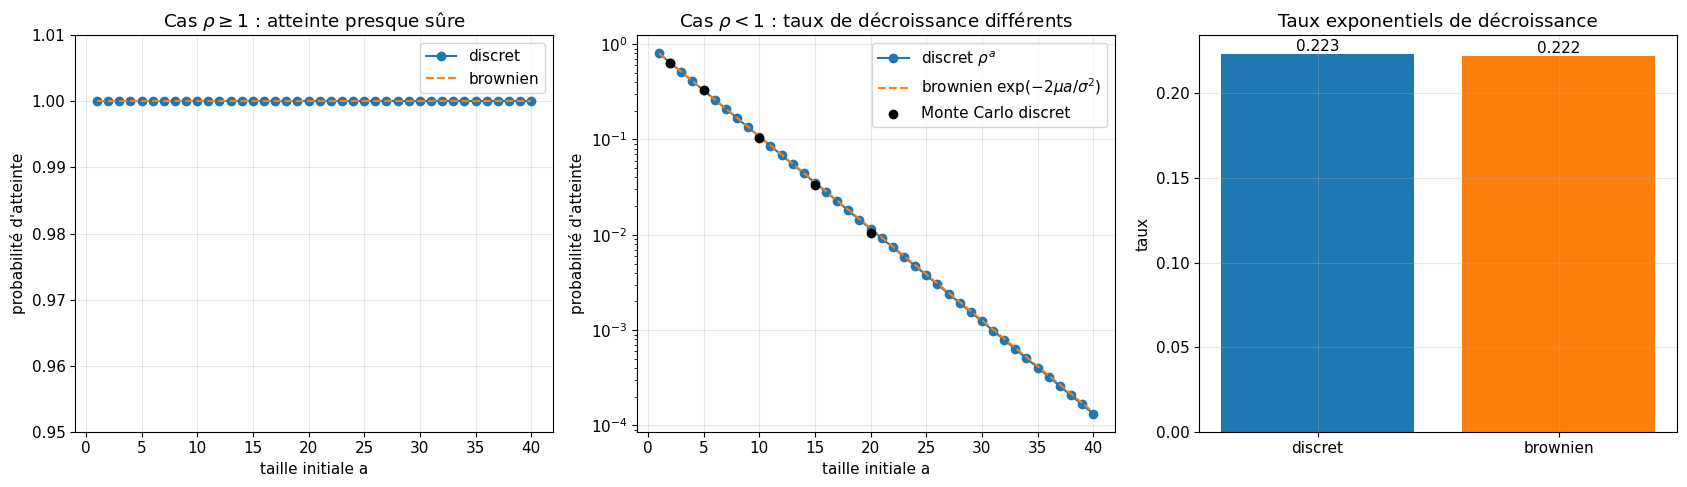

,a,MC discret,formule discrète ρ^a,formule brownienne
0,2,0.63750,0.640000,0.641180
1,5,0.32915,0.327680,0.329193
2,10,0.10290,0.107374,0.108368
3,15,0.03370,0.035184,0.035674
4,20,0.01050,0.011529,0.011744


In [9]:
def estimation_mc_atteinte_zero(a, lambda_plus, lambda_minus, n_runs=20_000, max_events=20_000, seed=42):
    # Validation Monte Carlo de la probabilité discrète d'atteinte de zéro.
    rng = np.random.default_rng(seed)
    succes = 0
    p_add = lambda_plus / (lambda_plus + lambda_minus)
    for _ in range(n_runs):
        q = int(a)
        for _ in range(max_events):
            q += 1 if rng.random() < p_add else -1
            if q <= 0:
                succes += 1
                break
            # Barrière haute numérique : si le processus s'éloigne beaucoup,
            # la probabilité conditionnelle restante devient négligeable.
            if q > 10 * max(a, 1) + 500:
                break
    return succes / n_runs


a_values = np.arange(1, 41)

# Cas ρ ≥ 1 : drift négatif, concordance parfaite P=1.
lp_down, lm_down = 1.2, 1.5
comp_down = compare_hitting_probabilities(a_values, lp_down, lm_down)

# Cas ρ < 1 : drift positif, probabilités strictement inférieures à 1.
lp_up, lm_up = 1.5, 1.2
comp_up = compare_hitting_probabilities(a_values, lp_up, lm_up)

a_mc = np.array([2, 5, 10, 15, 20])
p_mc = np.array([
    estimation_mc_atteinte_zero(a, lp_up, lm_up, n_runs=20_000, seed=SEED + int(a))
    for a in a_mc
])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(a_values, comp_down["p_discrete"], "o-", label="discret")
axes[0].plot(a_values, comp_down["p_brownian"], "--", label="brownien")
axes[0].set_ylim(0.95, 1.01)
axes[0].set_title(r"Cas $\rho\geq 1$ : atteinte presque sûre")
axes[0].set_xlabel("taille initiale a")
axes[0].set_ylabel("probabilité d'atteinte")
axes[0].legend()

axes[1].semilogy(a_values, comp_up["p_discrete"], "o-", label=r"discret $\rho^a$")
axes[1].semilogy(a_values, comp_up["p_brownian"], "--", label=r"brownien $\exp(-2\mu a/\sigma^2)$")
axes[1].scatter(a_mc, p_mc, color="black", zorder=5, label="Monte Carlo discret")
axes[1].set_title(r"Cas $\rho<1$ : taux de décroissance différents")
axes[1].set_xlabel("taille initiale a")
axes[1].set_ylabel("probabilité d'atteinte")
axes[1].legend()

taux_discret = -np.log(lm_up / lp_up)
taux_bm = 2 * (lp_up - lm_up) / (lp_up + lm_up)
axes[2].bar(["discret", "brownien"], [taux_discret, taux_bm], color=["tab:blue", "tab:orange"])
axes[2].set_title("Taux exponentiels de décroissance")
axes[2].set_ylabel("taux")
for i, v in enumerate([taux_discret, taux_bm]):
    axes[2].text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

pd.DataFrame({
    "a": a_mc,
    "MC discret": p_mc,
    "formule discrète ρ^a": (lm_up / lp_up) ** a_mc,
    "formule brownienne": np.exp(-2 * (lp_up - lm_up) * a_mc / (lp_up + lm_up)),
})

**Conclusion du complément.** Lorsque $\rho\ge 1$, le processus discret et
le brownien atteignent zéro avec probabilité $1$. Lorsque $\rho<1$, les
deux modèles prédisent une probabilité strictement inférieure à $1$, mais
la granularité discrète donne $\rho^a$, tandis que l'approximation continue
donne $\exp(-2\mu a/\sigma^2)$. Les simulations Monte Carlo valident la
formule discrète.
